# Phase III C4 Artificial-Viscosity Parameter Study (Accelerated SGS, 33 x 33)

This notebook studies the effect of the 4th-order artificial-viscosity coefficient `C^(4)` on the lid-driven cavity solution.

Unlike the `κ` study, which mainly tests time-derivative preconditioning and convergence behavior, this study changes the numerical dissipation directly through both solver coefficients:

- `Cx`
- `Cy`

The mesh is intentionally set to `33 x 33` and only three `C^(4)` values are tested so the study runs quickly. The baseline course value is `C^(4) = 0.01`.

In [1]:
from pathlib import Path
import contextlib
import io
import os
import shutil
import time

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if Path.cwd().name != "start-code" and (Path.cwd() / "start-code").exists():
    os.chdir(Path.cwd() / "start-code")

plot_dir = Path("Phase III C4 Study Accelerated 33x33")
plot_dir.mkdir(exist_ok=True)

print(f"Working directory: {Path.cwd()}")
print(f"Plot output directory: {plot_dir.resolve()}")

Working directory: /Users/windy/mae4100-courseproject2/start-code
Plot output directory: /Users/windy/mae4100-courseproject2/start-code/Phase III C4 Study Accelerated 33x33


In [2]:
# Quick C4 sensitivity settings.
NODE_COUNT = 33
REYNOLDS_NUMBER = 10.0
CFL = 0.5
KAPPA = 0.5
TOLERANCE = 1e-8

# Vary Cx and Cy together around the course default C^(4) = 0.01.
C4_VALUES = [0.0078, 0.01, 0.0600]

# Run one tiny accelerated case first so the Numba compile cost is paid before timing the study cases.
WARM_UP_ACCELERATED_SGS = True

pd.DataFrame({
    "nodes": [f"{NODE_COUNT}x{NODE_COUNT}"] * len(C4_VALUES),
    "Re": [REYNOLDS_NUMBER] * len(C4_VALUES),
    "CFL": [CFL] * len(C4_VALUES),
    "kappa": [KAPPA] * len(C4_VALUES),
    "tolerance": [TOLERANCE] * len(C4_VALUES),
    "C4": C4_VALUES,
})

,nodes,Re,CFL,kappa,tolerance,C4
0,33x33,10.0,0.5,0.5,1.000000e-08,0.0078
1,33x33,10.0,0.5,0.5,1.000000e-08,0.0100
2,33x33,10.0,0.5,0.5,1.000000e-08,0.0600


In [3]:
MAIN_PLOT_FILES = [
    "ucontour.png",
    "vcontour.png",
    "pcontour.png",
    "residualcomponent.png",
    "residual.png",
]


def replace_once(source, old, new, solver_path):
    if old not in source:
        raise RuntimeError(f"Could not find expected setting in {solver_path}: {old}")
    return source.replace(old, new, 1)


def format_solver_float(value):
    return f"{value:<16g}"


def c4_label(c4):
    return f"C4_{c4:g}".replace(".", "p")


def patched_solver_source(c4, node_count=NODE_COUNT, tolerance=TOLERANCE, max_iterations=None):
    solver_path = Path("main_solver.py")
    source = solver_path.read_text()

    replacements = {
        "imax = 9               # Number of points in the x-direction (use odd numbers only)":
            f"imax = {node_count:<15}# Number of points in the x-direction (use odd numbers only)",
        "jmax = 9               # Number of points in the y-direction (use odd numbers only)":
            f"jmax = {node_count:<15}# Number of points in the y-direction (use odd numbers only)",
        "iterout = 5000         # Number of time steps between solution output":
            "iterout = 100000000    # Number of time steps between solution output",
        "cfl = 0.5              # CFL number used to determine time step":
            f"cfl = {format_solver_float(CFL)}# CFL number used to determine time step",
        "toler = 1e-10          # Tolerance for iterative residual convergence":
            f"toler = {format_solver_float(tolerance)}# Tolerance for iterative residual convergence",
        "rkappa = 0.5           # Time derivative preconditioning constant":
            f"rkappa = {format_solver_float(KAPPA)}# Time derivative preconditioning constant",
        "Cx = 0.01              # Parameter for 4th order artificial viscosity in x":
            f"Cx = {format_solver_float(c4)}# Parameter for 4th order artificial viscosity in x",
        "Cy = 0.01              # Parameter for 4th order artificial viscosity in y":
            f"Cy = {format_solver_float(c4)}# Parameter for 4th order artificial viscosity in y",
        "Re = 10.0              # Reynolds number = rho*Uinf*L/rmu":
            f"Re = {format_solver_float(REYNOLDS_NUMBER)}# Reynolds number = rho*Uinf*L/rmu",
        "vectorize = False":
            "vectorize = True",
        "u = SGS_forward_sweep(u, uold, dt, s, rho, rhoinv, dx, dy, rkappa, rmu, vel2ref, artviscx, artviscy)":
            "u = SGS_forward_sweep_acc(u, uold, dt, s, rho, rhoinv, dx, dy, rkappa, rmu, vel2ref, artviscx, artviscy)",
        "u = SGS_backward_sweep(u, uold, dt, s, rho, rhoinv, dx, dy, rkappa, rmu, vel2ref, artviscx, artviscy)":
            "u = SGS_backward_sweep_acc(u, uold, dt, s, rho, rhoinv, dx, dy, rkappa, rmu, vel2ref, artviscx, artviscy)",
    }

    if max_iterations is not None:
        replacements["nmax = 500000          # Maximum number of iterations"] = (
            f"nmax = {max_iterations:<15}# Maximum number of iterations"
        )

    for old, new in replacements.items():
        source = replace_once(source, old, new, solver_path)

    return solver_path, source


def archive_solver_plots(case_label):
    for filename in MAIN_PLOT_FILES:
        src = Path(filename)
        if src.exists():
            dst = plot_dir / f"{case_label}_{filename}"
            if dst.exists():
                dst.unlink()
            shutil.move(str(src), str(dst))


def run_c4_case(c4, node_count=NODE_COUNT, tolerance=TOLERANCE, archive_plots=True, max_iterations=None):
    case_label = c4_label(c4)
    solver_path, source = patched_solver_source(
        c4,
        node_count=node_count,
        tolerance=tolerance,
        max_iterations=max_iterations,
    )
    namespace = {
        "__file__": str(solver_path.resolve()),
        "__name__": "__main__",
    }

    print(f"Running accelerated SGS: {node_count}x{node_count}, Re={REYNOLDS_NUMBER:g}, C4={c4:g}")
    start = time.perf_counter()
    with contextlib.redirect_stdout(io.StringIO()) as captured_output:
        exec(compile(source, str(solver_path), "exec"), namespace)
    elapsed = time.perf_counter() - start

    if archive_plots:
        archive_solver_plots(case_label)
    plt.close("all")

    u = namespace["u"].copy()
    imax, jmax, _ = u.shape
    i_mid = (imax - 1) // 2
    j_mid = (jmax - 1) // 2
    x_coords = np.linspace(namespace["xmin"], namespace["xmax"], imax)
    y_coords = np.linspace(namespace["ymin"], namespace["ymax"], jmax)

    return {
        "C4": c4,
        "label": case_label,
        "nodes": node_count,
        "Re": REYNOLDS_NUMBER,
        "CFL": CFL,
        "kappa": KAPPA,
        "tolerance": tolerance,
        "elapsed_time_sec": elapsed,
        "iterations": int(namespace["n"]),
        "converged": bool(namespace["isConverged"]),
        "final_conv": float(namespace["conv"]),
        "final_residual": np.array(namespace["res"], copy=True),
        "conv_history": np.array(namespace["convVector"], copy=True),
        "residual_history": np.array(namespace["resPMatrix"], copy=True),
        "x": x_coords,
        "y": y_coords,
        "u_vertical_centerline": u[i_mid, :, 1].copy(),
        "v_horizontal_centerline": u[:, j_mid, 2].copy(),
        "p_vertical_centerline": u[i_mid, :, 0].copy(),
        "p_horizontal_centerline": u[:, j_mid, 0].copy(),
        "captured_output": captured_output.getvalue(),
    }

In [4]:
if WARM_UP_ACCELERATED_SGS:
    print("Warming up accelerated SGS kernels on a small 9x9 case...")
    _warmup = run_c4_case(
        0.01,
        node_count=9,
        tolerance=1e-3,
        archive_plots=False,
        max_iterations=50,
    )
    print(f"Warm-up complete in {_warmup['elapsed_time_sec']:.2f} s")

results = []
for c4 in C4_VALUES:
    result = run_c4_case(c4)
    results.append(result)
    print(
        f"Finished C4={c4:g}: "
        f"iterations={result['iterations']}, "
        f"converged={result['converged']}, "
        f"final_conv={result['final_conv']:.3e}, "
        f"wall_time={result['elapsed_time_sec']:.2f} s"
    )

summary_table = pd.DataFrame([
    {
        "C4": result["C4"],
        "nodes": f"{result['nodes']}x{result['nodes']}",
        "Re": result["Re"],
        "CFL": result["CFL"],
        "kappa": result["kappa"],
        "tolerance": result["tolerance"],
        "iterations": result["iterations"],
        "converged": result["converged"],
        "final_conv": result["final_conv"],
        "wall_time_s": result["elapsed_time_sec"],
        "continuity_residual": result["final_residual"][0],
        "x_momentum_residual": result["final_residual"][1],
        "y_momentum_residual": result["final_residual"][2],
    }
    for result in results
]).sort_values("C4")

summary_table

Warming up accelerated SGS kernels on a small 9x9 case...
Running accelerated SGS: 9x9, Re=10, C4=0.01
Warm-up complete in 2.33 s
Running accelerated SGS: 33x33, Re=10, C4=0.0078
Finished C4=0.0078: iterations=6835, converged=True, final_conv=9.993e-09, wall_time=71.93 s
Running accelerated SGS: 33x33, Re=10, C4=0.01
Finished C4=0.01: iterations=6834, converged=True, final_conv=9.975e-09, wall_time=70.50 s
Running accelerated SGS: 33x33, Re=10, C4=0.06
Finished C4=0.06: iterations=6855, converged=True, final_conv=9.992e-09, wall_time=69.36 s


,C4,nodes,Re,CFL,kappa,tolerance,iterations,converged,final_conv,wall_time_s,continuity_residual,x_momentum_residual,y_momentum_residual
0,0.0078,33x33,10.0,0.5,0.5,1.000000e-08,6835,True,9.992948e-09,71.928948,2.173355e-09,2.314800e-12,9.992948e-09
1,0.0100,33x33,10.0,0.5,0.5,1.000000e-08,6834,True,9.975058e-09,70.502636,2.157760e-09,2.310374e-12,9.975058e-09
2,0.0600,33x33,10.0,0.5,0.5,1.000000e-08,6855,True,9.991834e-09,69.358607,2.071194e-09,2.316387e-12,9.991834e-09


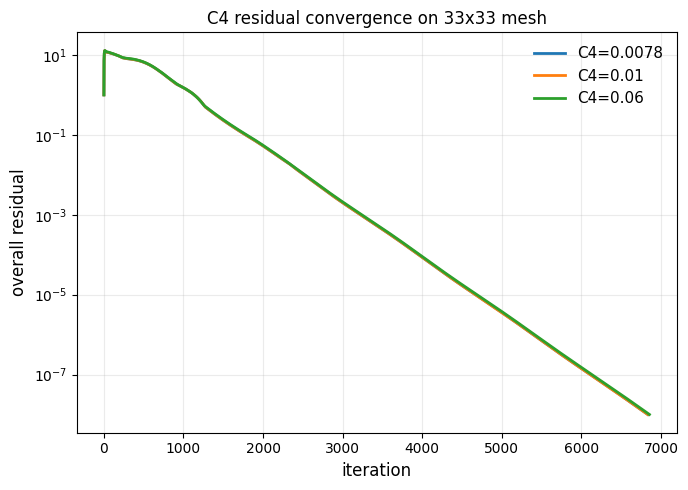

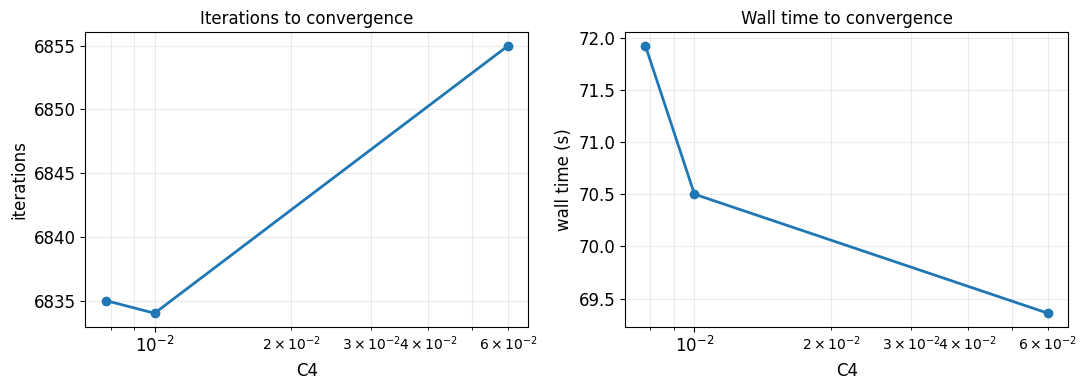

In [5]:
fontsize = 12

plt.figure(figsize=(7, 5))
for result in results:
    history = np.maximum(result["conv_history"], 1e-300)
    plt.semilogy(history, linewidth=2, label=f"C4={result['C4']:g}")
plt.xlabel("iteration", fontsize=fontsize)
plt.ylabel("overall residual", fontsize=fontsize)
plt.title(f"C4 residual convergence on {NODE_COUNT}x{NODE_COUNT} mesh", fontsize=fontsize)
plt.legend(loc="best", fontsize=fontsize - 1, frameon=False)
plt.grid(True, which="both", alpha=0.25)
plt.tight_layout()
plt.savefig(plot_dir / "c4_accelerated_residual_histories.png", dpi=300)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(summary_table["C4"], summary_table["iterations"], "o-", linewidth=2)
axes[0].set_xscale("log")
axes[0].set_xlabel("C4", fontsize=fontsize)
axes[0].set_ylabel("iterations", fontsize=fontsize)
axes[0].set_title("Iterations to convergence", fontsize=fontsize)

axes[1].plot(summary_table["C4"], summary_table["wall_time_s"], "o-", linewidth=2)
axes[1].set_xscale("log")
axes[1].set_xlabel("C4", fontsize=fontsize)
axes[1].set_ylabel("wall time (s)", fontsize=fontsize)
axes[1].set_title("Wall time to convergence", fontsize=fontsize)

for ax in axes:
    ax.tick_params(labelsize=fontsize)
    ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.savefig(plot_dir / "c4_accelerated_efficiency_summary.png", dpi=300)
plt.show()

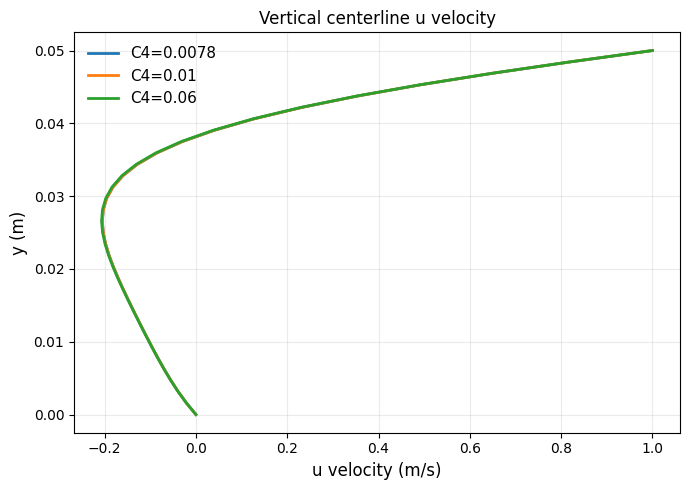

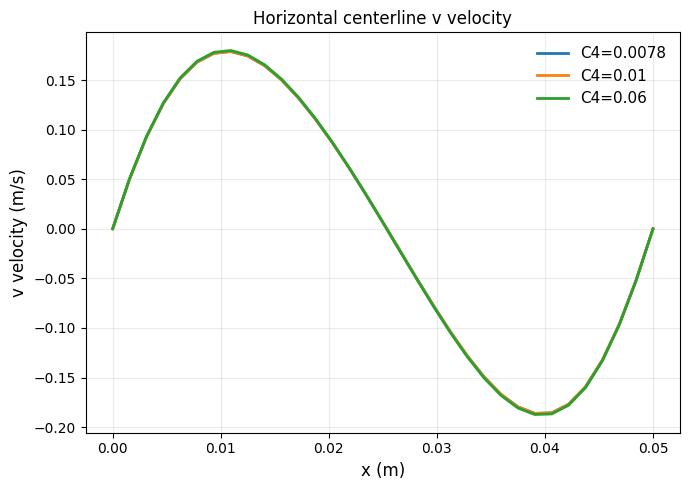

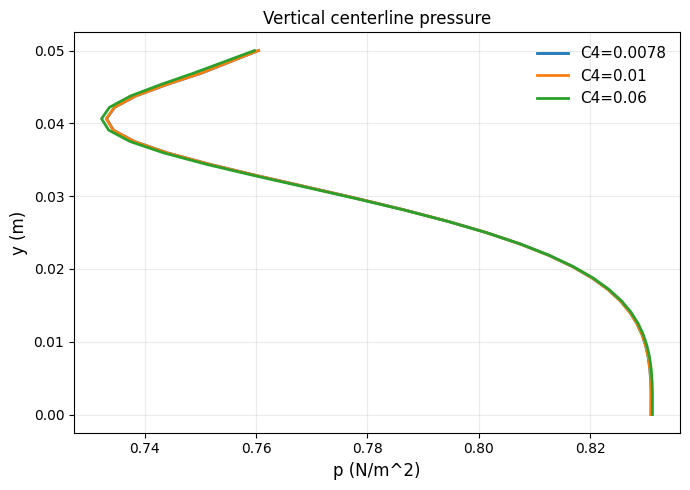

In [6]:
plt.figure(figsize=(7, 5))
for result in results:
    plt.plot(result["u_vertical_centerline"], result["y"], linewidth=2, label=f"C4={result['C4']:g}")
plt.xlabel("u velocity (m/s)", fontsize=fontsize)
plt.ylabel("y (m)", fontsize=fontsize)
plt.title("Vertical centerline u velocity", fontsize=fontsize)
plt.legend(loc="best", fontsize=fontsize - 1, frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(plot_dir / "c4_accelerated_vertical_centerline_u.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
for result in results:
    plt.plot(result["x"], result["v_horizontal_centerline"], linewidth=2, label=f"C4={result['C4']:g}")
plt.xlabel("x (m)", fontsize=fontsize)
plt.ylabel("v velocity (m/s)", fontsize=fontsize)
plt.title("Horizontal centerline v velocity", fontsize=fontsize)
plt.legend(loc="best", fontsize=fontsize - 1, frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(plot_dir / "c4_accelerated_horizontal_centerline_v.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
for result in results:
    plt.plot(result["p_vertical_centerline"], result["y"], linewidth=2, label=f"C4={result['C4']:g}")
plt.xlabel("p (N/m^2)", fontsize=fontsize)
plt.ylabel("y (m)", fontsize=fontsize)
plt.title("Vertical centerline pressure", fontsize=fontsize)
plt.legend(loc="best", fontsize=fontsize - 1, frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(plot_dir / "c4_accelerated_vertical_centerline_pressure.png", dpi=300)
plt.show()

In [7]:
# Quantify whether C4 changes the converged solution.
# The baseline is the course default C4 = 0.01 when included in C4_VALUES.
baseline = next((result for result in results if np.isclose(result["C4"], 0.01)), results[0])

profile_difference_table = pd.DataFrame([
    {
        "C4": result["C4"],
        "baseline_C4": baseline["C4"],
        "max_abs_delta_u_vertical_centerline": np.max(np.abs(result["u_vertical_centerline"] - baseline["u_vertical_centerline"])),
        "max_abs_delta_v_horizontal_centerline": np.max(np.abs(result["v_horizontal_centerline"] - baseline["v_horizontal_centerline"])),
        "max_abs_delta_p_vertical_centerline": np.max(np.abs(result["p_vertical_centerline"] - baseline["p_vertical_centerline"])),
    }
    for result in results
]).sort_values("C4")

profile_difference_table

,C4,baseline_C4,max_abs_delta_u_vertical_centerline,max_abs_delta_v_horizontal_centerline,max_abs_delta_p_vertical_centerline
0,0.0078,0.01,0.000122,0.000059,0.000086
1,0.0100,0.01,0.000000,0.000000,0.000000
2,0.0600,0.01,0.002279,0.001090,0.001342
